In [1]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from collections import defaultdict

base_real_path = "DiffusionEmotion_S/cropped"
csv_path = "DiffusionEmotion_S/dataset_sheet.csv"

# 4-class mapping: merge fear + disgust
emotion_map4 = {
    "happy": "happy",
    "sad": "sad",
    "angry": "angry",
    "fear": "fear",
    "disgust": "fear",
}

classes = ["happy", "sad", "angry", "fear"]
class_to_idx = {c:i for i,c in enumerate(classes)}
idx_to_class = {i:c for c,i in class_to_idx.items()}

df = pd.read_csv(csv_path)
df["raw_emotion"] = df["subDirectory_filePath"].apply(lambda p: p.split("/")[1].lower())
df["filename"]    = df["subDirectory_filePath"].apply(lambda p: p.split("/")[2])

df["real_path"] = df.apply(lambda r: os.path.join(base_real_path, r["raw_emotion"], r["filename"]), axis=1)
df = df[df["real_path"].apply(os.path.exists)].reset_index(drop=True)

df["mapped_emotion"] = df["raw_emotion"].map(emotion_map4)
df = df[df["mapped_emotion"].notna()].reset_index(drop=True)
df["label"] = df["mapped_emotion"].map(class_to_idx).astype(int)

print("Total images after filtering:", len(df))
print(df["mapped_emotion"].value_counts())

# stratified split 70/15/15
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
)

def show_dist(name, split):
    vc = split["mapped_emotion"].value_counts()
    print(f"\n{name} distribution:")
    for c in classes:
        print(f"  {c:12s}: {int(vc.get(c,0))}")

show_dist("Train", train_df)
show_dist("Val", val_df)
show_dist("Test", test_df)


Total images after filtering: 759
mapped_emotion
happy    340
angry    178
fear     160
sad       81
Name: count, dtype: int64

Train distribution:
  happy       : 238
  sad         : 57
  angry       : 124
  fear        : 112

Val distribution:
  happy       : 51
  sad         : 12
  angry       : 27
  fear        : 24

Test distribution:
  happy       : 51
  sad         : 12
  angry       : 27
  fear        : 24


In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image, UnidentifiedImageError
import torchvision.transforms as T
import torchvision.models as models
# best_path = "best_mnv3_4cls.pth"   # 你的权重文件名
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

IMG_SIZE = 224
BATCH = 64
EPOCHS = 10
LR = 3e-4

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

eval_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except (UnidentifiedImageError, OSError):
        return False

# 过滤坏图（和你原来的逻辑一致）
train_df = train_df[train_df["real_path"].apply(is_valid_image)].reset_index(drop=True)
val_df   = val_df[val_df["real_path"].apply(is_valid_image)].reset_index(drop=True)
test_df  = test_df[test_df["real_path"].apply(is_valid_image)].reset_index(drop=True)

class Emotion4Dataset(Dataset):
    def __init__(self, df, tfms):
        self.paths = df["real_path"].tolist()
        self.labels = df["label"].tolist()
        self.tfms = tfms

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        x = self.tfms(img)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

train_ds = Emotion4Dataset(train_df, train_tfms)
val_ds   = Emotion4Dataset(val_df,   eval_tfms)
test_ds  = Emotion4Dataset(test_df,  eval_tfms)

# ---- 不平衡：WeightedRandomSampler（让每个 batch 更均衡）----
train_labels = train_df["label"].to_numpy()
class_counts = np.bincount(train_labels, minlength=len(classes))
class_weights = (class_counts.sum() / (len(classes) * np.maximum(class_counts, 1))).astype(np.float32)

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float32),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

# ---- 模型：MobileNetV3 Small（最容易以后 Unity/ONNX）----
model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
model.classifier[3] = nn.Linear(model.classifier[3].in_features, len(classes))
model = model.to(device)

# ---- 不平衡：loss 也加 class weight（双保险）----
loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, device=device))
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

@torch.no_grad()
def eval_metrics(loader):
    model.eval()
    all_p, all_y = [], []
    for x,y in loader:
        x = x.to(device)
        logits = model(x)
        pred = logits.argmax(dim=1).cpu().numpy()
        all_p.append(pred)
        all_y.append(y.numpy())
    return np.concatenate(all_y), np.concatenate(all_p)

best_val_acc = 0.0
best_path = "best_mnv3_4cls.pth"

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    for x,y in train_loader:
        x,y = x.to(device), y.to(device)
        logits = model(x)
        loss = loss_fn(logits, y)
        opt.zero_grad()
        loss.backward()
        opt.step()
        total_loss += float(loss.item())

    yv, pv = eval_metrics(val_loader)
    val_acc = (yv == pv).mean()

    print(f"Epoch {epoch+1:02d} | loss={total_loss/len(train_loader):.4f} | val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "state_dict": model.state_dict(),
            "classes": classes,
            "img_size": IMG_SIZE,
            "mean": MEAN,
            "std": STD,
        }, best_path)
        print("Saved best:", best_path)

print("Best val acc:", best_val_acc)


device: cuda
Epoch 01 | loss=1.1605 | val_acc=0.2632
Saved best: best_mnv3_4cls.pth
Epoch 02 | loss=0.7531 | val_acc=0.3772
Saved best: best_mnv3_4cls.pth
Epoch 03 | loss=0.5079 | val_acc=0.5877
Saved best: best_mnv3_4cls.pth
Epoch 04 | loss=0.3328 | val_acc=0.6754
Saved best: best_mnv3_4cls.pth
Epoch 05 | loss=0.2125 | val_acc=0.7456
Saved best: best_mnv3_4cls.pth
Epoch 06 | loss=0.1260 | val_acc=0.7632
Saved best: best_mnv3_4cls.pth
Epoch 07 | loss=0.1474 | val_acc=0.7632
Epoch 08 | loss=0.0560 | val_acc=0.7544
Epoch 09 | loss=0.0473 | val_acc=0.7895
Saved best: best_mnv3_4cls.pth
Epoch 10 | loss=0.0276 | val_acc=0.8246
Saved best: best_mnv3_4cls.pth
Best val acc: 0.8245614035087719



===== Test Report =====
              precision    recall  f1-score   support

       happy     0.7846    1.0000    0.8793        51
         sad     0.8750    0.5833    0.7000        12
       angry     0.8421    0.5926    0.6957        27
        fear     0.7727    0.7083    0.7391        24

    accuracy                         0.7982       114
   macro avg     0.8186    0.7211    0.7535       114
weighted avg     0.8052    0.7982    0.7874       114

macro-F1: 0.7535232383808095


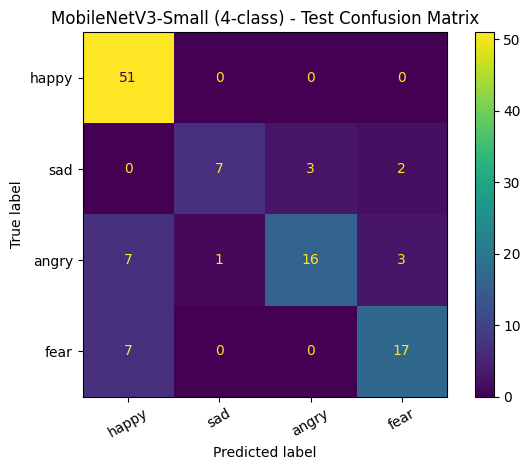

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["state_dict"])

yt, pt = eval_metrics(test_loader)

print("\n===== Test Report =====")
print(classification_report(yt, pt, target_names=classes, digits=4))
print("macro-F1:", f1_score(yt, pt, average="macro"))

cm = confusion_matrix(yt, pt, labels=list(range(len(classes))))
disp = ConfusionMatrixDisplay(cm, display_labels=classes)
disp.plot(xticks_rotation=30)
plt.title("MobileNetV3-Small (4-class) - Test Confusion Matrix")
plt.tight_layout()
plt.show()


In [4]:
# import cv2
# import time
# import numpy as np
# import mediapipe as mp
# import torch
# from collections import deque
# from PIL import Image

# # ---- 加载 best 模型 ----
# ckpt = torch.load(best_path, map_location=device)
# model.load_state_dict(ckpt["state_dict"])
# model.eval()

# IMG_SIZE = ckpt["img_size"]
# MEAN = np.array(ckpt["mean"], dtype=np.float32)
# STD  = np.array(ckpt["std"],  dtype=np.float32)

# def preprocess_face(face_bgr):
#     face_rgb = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)
#     img = Image.fromarray(face_rgb).resize((IMG_SIZE, IMG_SIZE))
#     x = np.asarray(img).astype(np.float32) / 255.0
#     x = (x - MEAN) / STD
#     x = np.transpose(x, (2,0,1))[None, ...]  # NCHW
#     return torch.tensor(x, dtype=torch.float32, device=device)

# def softmax_np(z):
#     z = z - np.max(z)
#     e = np.exp(z)
#     return e / (e.sum() + 1e-9)

# # ---- 平滑参数 ----
# SMOOTH_N = 15          # 越大越稳但延迟更高
# UNKNOWN_TH = 0.55      # 置信度阈值，低于显示 Unknown
# PAD_RATIO = 0.20       # 人脸框扩大一点

# mp_fd = mp.solutions.face_detection
# fd = mp_fd.FaceDetection(model_selection=0, min_detection_confidence=0.5)

# cap = cv2.VideoCapture(0)
# if not cap.isOpened():
#     raise RuntimeError("Cannot open webcam")

# # 用一个全局平滑队列（简单版；如果多人可按 bbox 做 key）
# logit_hist = deque(maxlen=SMOOTH_N)

# print("Press q to quit.")
# while True:
#     ok, frame = cap.read()
#     if not ok:
#         break
#     H, W = frame.shape[:2]

#     rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
#     res = fd.process(rgb)

#     if res.detections:
#         # 取第一张脸（你们游戏也通常只关心对面一个人）
#         det = res.detections[0]
#         bb = det.location_data.relative_bounding_box
#         x1 = int(bb.xmin * W)
#         y1 = int(bb.ymin * H)
#         ww = int(bb.width * W)
#         hh = int(bb.height * H)

#         # pad
#         padw = int(ww * PAD_RATIO)
#         padh = int(hh * PAD_RATIO)
#         x1p = max(0, x1 - padw)
#         y1p = max(0, y1 - padh)
#         x2p = min(W, x1 + ww + padw)
#         y2p = min(H, y1 + hh + padh)

#         face = frame[y1p:y2p, x1p:x2p]
#         if face.size > 0:
#             x = preprocess_face(face)
#             with torch.no_grad():
#                 logits = model(x)[0].detach().cpu().numpy()  # (4,)
#             logit_hist.append(logits)

#             avg_logits = np.mean(np.stack(logit_hist, axis=0), axis=0)
#             probs = softmax_np(avg_logits)
#             idx = int(np.argmax(probs))
#             conf = float(probs[idx])
#             label = classes[idx] if conf >= UNKNOWN_TH else "Unknown"

#             # draw
#             cv2.rectangle(frame, (x1p,y1p), (x2p,y2p), (0,255,0), 2)
#             cv2.putText(frame, f"{label} ({conf:.2f})",
#                         (x1p, max(0, y1p-10)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)
#     else:
#         logit_hist.clear()  # 没脸就清空平滑

#     cv2.imshow("Webcam - MediaPipe FaceDetection + MobileNetV3 emotion", frame)
#     if cv2.waitKey(1) & 0xFF == ord("q"):
#         break

# cap.release()
# cv2.destroyAllWindows()
# fd.close()


In [5]:
# import mediapipe as mp
# import inspect, os
# print("mp module file:", mp.__file__)
# print("mp version:", getattr(mp, "__version__", "no __version__"))
# print("has solutions:", hasattr(mp, "solutions"))


In [6]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
from PIL import Image
from collections import deque

# ========== 1) 配置：把权重文件路径写对 ==========
best_path = "best_mnv3_4cls.pth"  # 如果不在当前目录，改成绝对路径 r"C:\...\best_mnv3_4cls.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("cwd:", os.getcwd())
print("weight exists:", os.path.exists(best_path))
assert os.path.exists(best_path), f"not found: {best_path}"

# ========== 2) 加载 ckpt 并重建模型（单独cell可跑，不依赖前面变量） ==========
ckpt = torch.load(best_path, map_location=device)
classes = ckpt["classes"]              # e.g. ["happy","sad","angry","fear"]
IMG_SIZE = int(ckpt["img_size"])
MEAN = np.array(ckpt["mean"], dtype=np.float32)
STD  = np.array(ckpt["std"],  dtype=np.float32)

model = models.mobilenet_v3_small(weights=None)
model.classifier[3] = nn.Linear(model.classifier[3].in_features, len(classes))
model.load_state_dict(ckpt["state_dict"])
model.to(device).eval()

def preprocess_face(face_bgr: np.ndarray) -> torch.Tensor:
    face_rgb = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)
    img = Image.fromarray(face_rgb).resize((IMG_SIZE, IMG_SIZE))
    x = np.asarray(img).astype(np.float32) / 255.0
    x = (x - MEAN) / STD
    x = np.transpose(x, (2, 0, 1))[None, ...]  # NCHW
    return torch.tensor(x, dtype=torch.float32, device=device)

def softmax_np(z: np.ndarray) -> np.ndarray:
    z = z - np.max(z)
    e = np.exp(z)
    return e / (e.sum() + 1e-9)

# ========== 3) Haar 人脸检测器 ==========
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
if face_cascade.empty():
    raise RuntimeError("Cannot load haarcascade_frontalface_default.xml (check OpenCV installation)")

# ========== 4) 可调参数 ==========
PAD_RATIO = 0.25         # 人脸框扩大比例
SMOOTH_N = 15            # 平滑窗口长度（15帧大概 0.5 秒）
UNKNOWN_TH = 0.55        # 情绪置信度阈值（低于则 Unknown）
MIN_FACE = (90, 90)      # 最小人脸尺寸，太小的不要（减少误检）

logit_hist = deque(maxlen=SMOOTH_N)

# ========== 5) 打开摄像头 ==========
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise RuntimeError("Cannot open webcam (VideoCapture(0) failed).")

print("Press 'q' to quit.")
while True:
    ok, frame = cap.read()
    if not ok:
        print("Failed to read frame.")
        break

    H, W = frame.shape[:2]
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=MIN_FACE
    )

    if len(faces) > 0:
        # 选最大的脸（通常就是对面那个人）
        x, y, w, h = max(faces, key=lambda b: b[2] * b[3])

        # pad
        padw, padh = int(w * PAD_RATIO), int(h * PAD_RATIO)
        x1 = max(0, x - padw)
        y1 = max(0, y - padh)
        x2 = min(W, x + w + padw)
        y2 = min(H, y + h + padh)

        face = frame[y1:y2, x1:x2]
        if face.size > 0:
            x_in = preprocess_face(face)

            with torch.no_grad():
                logits = model(x_in)[0].detach().cpu().numpy()  # (4,)

            logit_hist.append(logits)

            avg_logits = np.mean(np.stack(logit_hist, axis=0), axis=0)
            probs = softmax_np(avg_logits)
            idx = int(np.argmax(probs))
            conf = float(probs[idx])

            label = classes[idx] if conf >= UNKNOWN_TH else "Unknown"

            # draw box + label
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(
                frame,
                f"{label} ({conf:.2f})",
                (x1, max(0, y1 - 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 255, 0),
                2
            )
    else:
        # 没检测到脸就清空平滑，避免“记忆残留”
        logit_hist.clear()

    cv2.imshow("Webcam - Haar Face + MobileNetV3 Emotion", frame)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()
print("Done.")


cwd: c:\Users\Lenovo\robot\lab1
weight exists: True
Press 'q' to quit.


KeyboardInterrupt: 

: 

In [ ]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
from PIL import Image
from collections import deque

best_path = "best_mnv3_4cls.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert os.path.exists(best_path), f"not found: {best_path}"

ckpt = torch.load(best_path, map_location=device)
classes = ckpt["classes"]
IMG_SIZE = int(ckpt["img_size"])
MEAN = np.array(ckpt["mean"], dtype=np.float32)
STD  = np.array(ckpt["std"],  dtype=np.float32)

model = models.mobilenet_v3_small(weights=None)
model.classifier[3] = nn.Linear(model.classifier[3].in_features, len(classes))
model.load_state_dict(ckpt["state_dict"])
model.to(device).eval()

def preprocess_face(face_bgr):
    face_rgb = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)
    img = Image.fromarray(face_rgb).resize((IMG_SIZE, IMG_SIZE))
    x = np.asarray(img).astype(np.float32) / 255.0
    x = (x - MEAN) / STD
    x = np.transpose(x, (2, 0, 1))[None, ...]
    return torch.tensor(x, dtype=torch.float32, device=device)

def softmax_np(z):
    z = z - np.max(z)
    e = np.exp(z)
    return e / (e.sum() + 1e-9)

# Haar detector
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
if face_cascade.empty():
    raise RuntimeError("Cannot load haarcascade_frontalface_default.xml")

# params
PAD_RATIO = 0.25
SMOOTH_N = 30         # 提高平滑，减少跳动（你可以试 30/45）
MIN_FACE = (90, 90)

logit_hist = deque(maxlen=SMOOTH_N)

# 永不 Unknown：默认初始情绪（可改成你最想要的）
last_label = classes[0]
last_conf = 0.0

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise RuntimeError("Cannot open webcam")

print("Press q to quit.")
while True:
    ok, frame = cap.read()
    if not ok:
        break

    H, W = frame.shape[:2]
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=MIN_FACE)

    if len(faces) > 0:
        x, y, w, h = max(faces, key=lambda b: b[2] * b[3])

        padw, padh = int(w * PAD_RATIO), int(h * PAD_RATIO)
        x1 = max(0, x - padw); y1 = max(0, y - padh)
        x2 = min(W, x + w + padw); y2 = min(H, y + h + padh)

        face = frame[y1:y2, x1:x2]
        if face.size > 0:
            x_in = preprocess_face(face)
            with torch.no_grad():
                logits = model(x_in)[0].detach().cpu().numpy()  # (4,)

            logit_hist.append(logits)
            avg_logits = np.mean(np.stack(logit_hist, axis=0), axis=0)
            probs = softmax_np(avg_logits)

            idx = int(np.argmax(probs))
            conf = float(probs[idx])

            # 永远输出 top-1
            last_label = classes[idx]
            last_conf = conf

            # draw face box
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0), 2)

    else:
        # 没脸：不更新情绪，保持 last_label（依然不会 Unknown）
        # 如果你坚持“没脸也要输出新的”，可以在这里随机/轮换
        logit_hist.clear()

    cv2.putText(frame, f"{last_label} ({last_conf:.2f})",
                (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0,255,0), 2)

    cv2.imshow("Webcam - Haar + MobileNetV3 (No Unknown)", frame)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()
print("Done.")


Press q to quit.
Done.


In [ ]:
import os
import json
import argparse

import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision.transforms as T
import torchvision.models as models


# -------------------------
# Utils
# -------------------------
def set_seed(seed: int = 42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def is_valid_image(path: str) -> bool:
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except (UnidentifiedImageError, OSError):
        return False


@torch.no_grad()
def eval_metrics(model, loader, device):
    model.eval()
    all_p, all_y = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        pred = logits.argmax(dim=1).cpu().numpy()
        all_p.append(pred)
        all_y.append(y.numpy())
    return np.concatenate(all_y), np.concatenate(all_p)


# -------------------------
# Dataset
# -------------------------
class EmotionDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tfms):
        self.paths = df["real_path"].tolist()
        self.labels = df["label"].tolist()
        self.tfms = tfms

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        x = self.tfms(img)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--base_real_path", type=str, default="DiffusionEmotion_S/cropped")
    parser.add_argument("--csv_path", type=str, default="DiffusionEmotion_S/dataset_sheet.csv")

    parser.add_argument("--img_size", type=int, default=224)
    parser.add_argument("--batch", type=int, default=64)
    parser.add_argument("--epochs", type=int, default=10)
    parser.add_argument("--lr", type=float, default=3e-4)
    parser.add_argument("--seed", type=int, default=42)

    parser.add_argument("--out_dir", type=str, default="export_out")
    parser.add_argument("--opset", type=int, default=13)

    args = parser.parse_args()
    set_seed(args.seed)

    os.makedirs(args.out_dir, exist_ok=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("device:", device)

    # 4-class mapping: merge fear + disgust -> fear
    emotion_map4 = {
        "happy": "happy",
        "sad": "sad",
        "angry": "angry",
        "fear": "fear",
        "disgust": "fear",
    }
    classes = ["happy", "sad", "angry", "fear"]
    class_to_idx = {c: i for i, c in enumerate(classes)}

    # -------------------------
    # Load CSV + build paths
    # -------------------------
    df = pd.read_csv(args.csv_path)
    df["raw_emotion"] = df["subDirectory_filePath"].apply(lambda p: p.split("/")[1].lower())
    df["filename"] = df["subDirectory_filePath"].apply(lambda p: p.split("/")[2])
    df["real_path"] = df.apply(
        lambda r: os.path.join(args.base_real_path, r["raw_emotion"], r["filename"]),
        axis=1,
    )
    df = df[df["real_path"].apply(os.path.exists)].reset_index(drop=True)

    df["mapped_emotion"] = df["raw_emotion"].map(emotion_map4)
    df = df[df["mapped_emotion"].notna()].reset_index(drop=True)
    df["label"] = df["mapped_emotion"].map(class_to_idx).astype(int)

    print("Total images after filtering:", len(df))
    print(df["mapped_emotion"].value_counts())

    # stratified split 70/15/15
    train_df, temp_df = train_test_split(
        df, test_size=0.30, stratify=df["label"], random_state=args.seed
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=0.50, stratify=temp_df["label"], random_state=args.seed
    )

    # filter bad images
    train_df = train_df[train_df["real_path"].apply(is_valid_image)].reset_index(drop=True)
    val_df = val_df[val_df["real_path"].apply(is_valid_image)].reset_index(drop=True)
    test_df = test_df[test_df["real_path"].apply(is_valid_image)].reset_index(drop=True)

    # -------------------------
    # Preprocess (Unity side must match)
    # -------------------------
    MEAN = [0.485, 0.456, 0.406]
    STD = [0.229, 0.224, 0.225]

    train_tfms = T.Compose([
        T.Resize((args.img_size, args.img_size)),
        T.RandomHorizontalFlip(p=0.5),
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        T.ToTensor(),
        T.Normalize(MEAN, STD),
    ])
    eval_tfms = T.Compose([
        T.Resize((args.img_size, args.img_size)),
        T.ToTensor(),
        T.Normalize(MEAN, STD),
    ])

    train_ds = EmotionDataset(train_df, train_tfms)
    val_ds = EmotionDataset(val_df, eval_tfms)
    test_ds = EmotionDataset(test_df, eval_tfms)

    # class weights + sampler
    train_labels = train_df["label"].to_numpy()
    class_counts = np.bincount(train_labels, minlength=len(classes))
    class_weights = (class_counts.sum() / (len(classes) * np.maximum(class_counts, 1))).astype(np.float32)

    sample_weights = class_weights[train_labels]
    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.float32),
        num_samples=len(sample_weights),
        replacement=True
    )

    train_loader = DataLoader(train_ds, batch_size=args.batch, sampler=sampler, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

    # -------------------------
    # Model: MobileNetV2 (ONNX/Unity friendlier than v3)
    # -------------------------
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(classes))
    model = model.to(device)

    loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, device=device))
    opt = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=1e-4)

    best_val_acc = 0.0
    best_path = os.path.join(args.out_dir, "best_emotion_mnv2.pth")

    # -------------------------
    # Train
    # -------------------------
    for epoch in range(args.epochs):
        model.train()
        total_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = loss_fn(logits, y)

            opt.zero_grad()
            loss.backward()
            opt.step()

            total_loss += float(loss.item())

        yv, pv = eval_metrics(model, val_loader, device)
        val_acc = float((yv == pv).mean())

        print(f"Epoch {epoch+1:02d} | loss={total_loss/len(train_loader):.4f} | val_acc={val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                "state_dict": model.state_dict(),
                "classes": classes,
                "img_size": args.img_size,
                "mean": MEAN,
                "std": STD,
                "arch": "mobilenet_v2",
            }, best_path)
            print("Saved best:", best_path)

    print("Best val acc:", best_val_acc)

    # -------------------------
    # Test Report (optional but useful)
    # -------------------------
    ckpt = torch.load(best_path, map_location=device)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()

    yt, pt = eval_metrics(model, test_loader, device)
    print("\n===== Test Report =====")
    print(classification_report(yt, pt, target_names=classes, digits=4))
    print("macro-F1:", f1_score(yt, pt, average="macro"))

    # -------------------------
    # Export ONNX
    # -------------------------
    onnx_path = os.path.join(args.out_dir, "emotion_mnv2_4cls.onnx")
    dummy = torch.randn(1, 3, args.img_size, args.img_size, device=device)

    torch.onnx.export(
        model.eval(),
        dummy,
        onnx_path,
        export_params=True,
        opset_version=args.opset,
        do_constant_folding=True,
        input_names=["input"],
        output_names=["logits"],
        dynamic_axes={"input": {0: "batch"}, "logits": {0: "batch"}},
    )
    print("Saved ONNX:", onnx_path)

    # ONNX check (does not require onnxruntime)
    try:
        import onnx
        onnx_model = onnx.load(onnx_path)
        onnx.checker.check_model(onnx_model)
        print("ONNX check: OK")
    except Exception as e:
        print("ONNX check: FAILED ->", repr(e))

    # -------------------------
    # Save Unity metadata
    # -------------------------
    labels_path = os.path.join(args.out_dir, "labels.json")
    preprocess_path = os.path.join(args.out_dir, "preprocess.json")

    with open(labels_path, "w", encoding="utf-8") as f:
        json.dump({"classes": classes}, f, ensure_ascii=False, indent=2)

    with open(preprocess_path, "w", encoding="utf-8") as f:
        json.dump(
            {
                "img_size": args.img_size,
                "mean": MEAN,
                "std": STD,
                "input_layout": "NCHW",
                "input_dtype": "float32",
                "output": "logits",
                "note": "Unity端预处理: RGB->float[0..1], (x-mean)/std, 变为NCHW"
            },
            f,
            ensure_ascii=False,
            indent=2
        )

    print("Saved:", labels_path)
    print("Saved:", preprocess_path)


if __name__ == "__main__":
    main()


usage: ipykernel_launcher.py [-h] [--base_real_path BASE_REAL_PATH]
                             [--csv_path CSV_PATH] [--img_size IMG_SIZE]
                             [--batch BATCH] [--epochs EPOCHS] [--lr LR]
                             [--seed SEED] [--out_dir OUT_DIR] [--opset OPSET]
ipykernel_launcher.py: error: unrecognized arguments: --ip=127.0.0.1 --stdin=9011 --control=9009 --hb=9008 --Session.signature_scheme="hmac-sha256" --Session.key=b"1d585607-f026-4bb9-9160-0df2167c8d0c" --shell=9010 --transport="tcp" --iopub=9012 --f=c:\Users\Lenovo\AppData\Roaming\jupyter\runtime\kernel-v2-23148NivyA5Watac7.json


SystemExit: 2